In [1]:
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import ROOT

from coincidence_lib import WaveformAnalyzer


/home/leoperes/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [9]:

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

INPUT_LIST = Path("../input_run039512.txt")
CONFIG_FILE = Path("waveform_intervals.ini")
MAX_AUXILIARY_AMPLITUDE_ADC = 500.0

CSV_FILE = "waveforms_run_039512_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.csv"

LABEL = CSV_FILE.replace(".csv", "").replace("waveforms_", "")
# ------------------------------------------------------------------
# Read selected waveform information
# ------------------------------------------------------------------

selected = pd.read_csv(CSV_FILE)

required_columns = {"event", "channel", "waveform_index_save"}
missing_columns = required_columns - set(selected.columns)

if missing_columns:
    raise ValueError(f"Missing CSV columns: {sorted(missing_columns)}")

selected_keys = {
    (int(row.event), int(row.channel), int(row.waveform_index_save))
    for row in selected.itertuples()
}

selected_channels = sorted(selected["channel"].astype(int).unique())

print(f"Selected CSV rows: {len(selected):,}")
print(f"Selected channels: {selected_channels}")

# ------------------------------------------------------------------
# Read ROOT filenames relative to input_list.txt
# ------------------------------------------------------------------

root_files = []

for line in INPUT_LIST.read_text().splitlines():
    line = line.strip()

    if line and not line.startswith("#"):
        root_files.append(
            str((INPUT_LIST.parent / line).resolve())
        )

if not root_files:
    raise RuntimeError(f"No ROOT files found in {INPUT_LIST}")

chain = ROOT.TChain("WaveformTree")

for filename in root_files:
    if chain.Add(filename) == 0:
        raise RuntimeError(f"Could not add ROOT file: {filename}")

print(f"ROOT files: {len(root_files)}")
print(f"Tree entries: {chain.GetEntries():,}")


Selected CSV rows: 35,568
Selected channels: [2070, 2071, 2080, 2081]
ROOT files: 6
Tree entries: 8,226,397


In [10]:

# ------------------------------------------------------------------
# Locate selected ROOT entry numbers without loading ADC vectors
# ------------------------------------------------------------------

channel_filter = " || ".join(
    f"channel == {channel}" for channel in selected_channels
)

metadata = (
    ROOT.RDataFrame(chain)
    .Filter(f"({channel_filter})")
    .Define("entry_index", "rdfentry_")
    .AsNumpy(
        ["entry_index", "event", "channel", "waveform_index"]
    )
)

entry_by_key = {}

for entry, event, channel, waveform_index in zip(
    metadata["entry_index"],
    metadata["event"],
    metadata["channel"],
    metadata["waveform_index"],
):
    key = (
        int(event),
        int(channel),
        int(waveform_index),
    )

    if key in selected_keys:
        entry_by_key[key] = int(entry)

missing_keys = selected_keys - set(entry_by_key)

if missing_keys:
    examples = sorted(missing_keys)[:10]
    raise RuntimeError(
        f"{len(missing_keys)} selected waveforms were not found. "
        f"Examples: {examples}"
    )

print(f"Located ROOT entries: {len(entry_by_key):,}")

# ------------------------------------------------------------------
# Choose a limited number per channel and load only their ADC vectors
# ------------------------------------------------------------------

keys_to_load = []

for channel in selected_channels:
    channel_rows = selected[
        selected["channel"].astype(int) == channel
    ]

    for row in channel_rows.itertuples():
        key = (
            int(row.event),
            int(row.channel),
            int(row.waveform_index_save),
        )
        keys_to_load.append(key)

# Reading in ROOT-entry order reduces file seeking.
keys_to_load.sort(key=lambda key: entry_by_key[key])

chain.SetBranchStatus("*", 0)
chain.SetBranchStatus("adc", 1)

analyzer = WaveformAnalyzer(CONFIG_FILE)
waveforms_by_channel = defaultdict(list)
rejected_noise = 0
rejected_post_signal = 0
rejected_total = 0

for key in keys_to_load:
    entry = entry_by_key[key]

    if chain.GetEntry(entry) <= 0:
        raise RuntimeError(f"Could not read ROOT entry {entry}")

    adc = np.fromiter(
        chain.adc,
        dtype=np.int16,
        count=len(chain.adc),
    )

    event, channel, waveform_index = key
    baseline = analyzer.noise_baseline(adc, channel)
    noise_amplitude = float(
        np.max(analyzer.region(adc, channel, "noise")) - baseline
    )
    post_signal_amplitude = float(
        np.max(analyzer.region(adc, channel, "post_signal")) - baseline
    )

    fails_noise = noise_amplitude > MAX_AUXILIARY_AMPLITUDE_ADC
    fails_post_signal = (
        post_signal_amplitude > MAX_AUXILIARY_AMPLITUDE_ADC
    )

    rejected_noise += int(fails_noise)
    rejected_post_signal += int(fails_post_signal)

    # Apply both quality cuts: reject if either region exceeds the limit.
    if fails_noise or fails_post_signal:
        rejected_total += 1
        continue

    waveforms_by_channel[channel].append(
        {
            "event": event,
            "waveform_index": waveform_index,
            "baseline": baseline,
            "noise_amplitude": noise_amplitude,
            "post_signal_amplitude": post_signal_amplitude,
            "adc": adc,
        }
    )

print(
    f"Retained {len(keys_to_load) - rejected_total:,} of "
    f"{len(keys_to_load):,} selected waveforms"
)
print(
    f"Rejected {rejected_total:,} unique waveforms: "
    f"{rejected_noise:,} exceeded the noise-region limit and "
    f"{rejected_post_signal:,} exceeded the post-signal limit "
    f"of {MAX_AUXILIARY_AMPLITUDE_ADC:g} ADC"
)


Located ROOT entries: 35,568
Retained 34,123 of 35,568 selected waveforms
Rejected 1,445 unique waveforms: 30 exceeded the noise-region limit and 1,415 exceeded the post-signal limit of 500 ADC


Saved channel_2070_run_039512_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.pdf
Saved channel_2071_run_039512_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.pdf
Saved channel_2080_run_039512_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.pdf
Saved channel_2081_run_039512_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.pdf


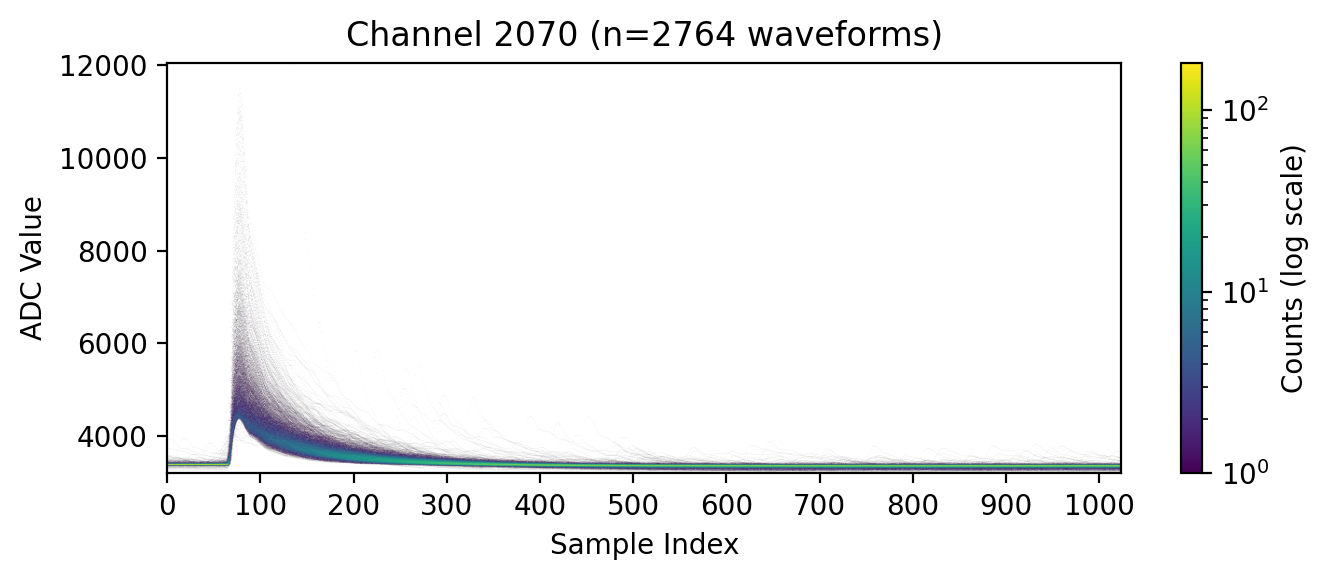

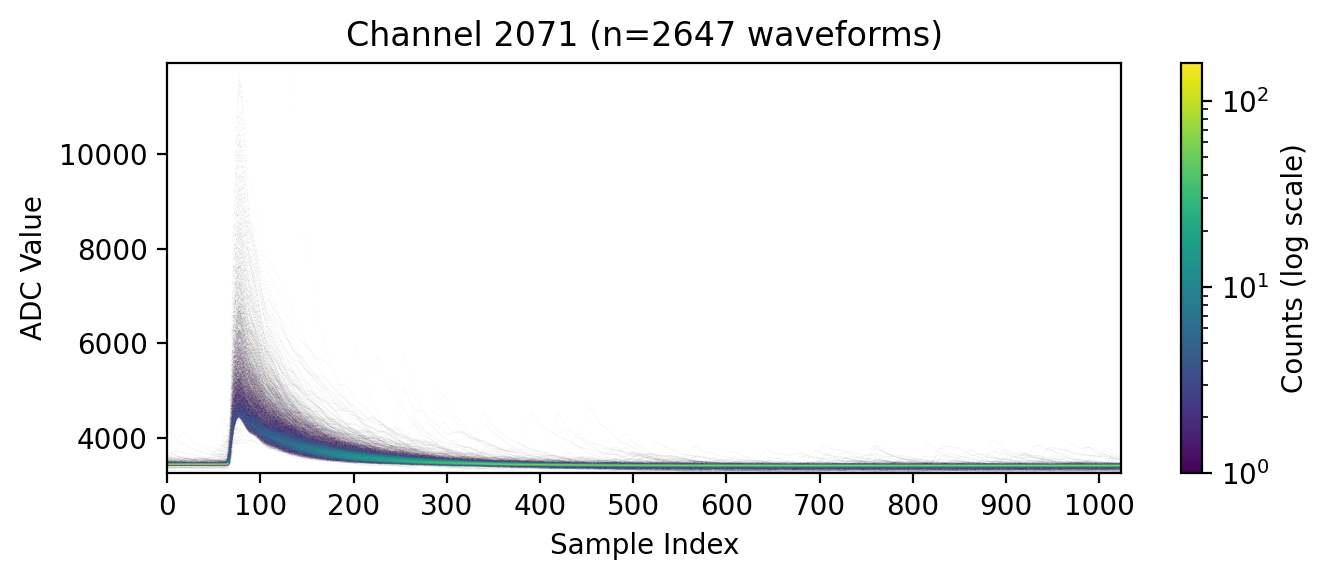

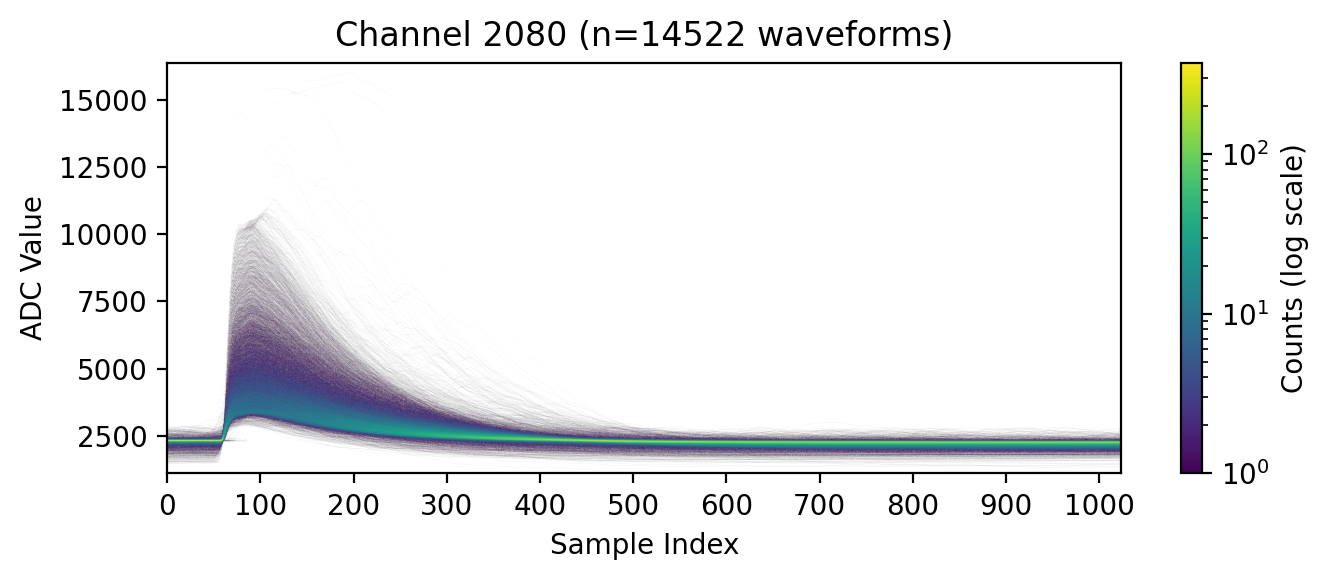

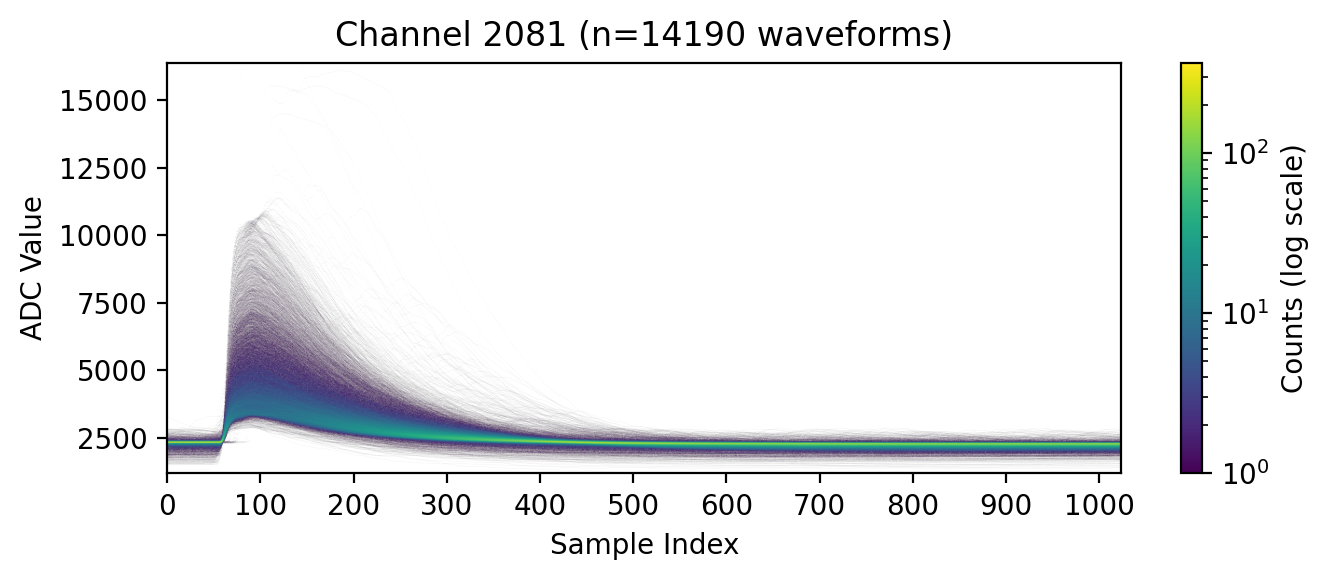

In [11]:
# ------------------------------------------------------------------
# Plot waveform-density histogram for each channel
# ------------------------------------------------------------------

for channel in selected_channels:
    records = waveforms_by_channel[channel]
    count = len(records)

    if count == 0:
        continue

    if any(len(record["adc"]) == 0 for record in records):
        raise RuntimeError(f"Channel {channel} contains an empty waveform")

    n_samples = max(len(record["adc"]) for record in records)
    adc_min = min(int(record["adc"].min()) for record in records)
    adc_max = max(int(record["adc"].max()) for record in records)

    # h[sample, ADC value] contains the number of waveforms passing
    # through that ADC value at that sample.
    h = np.zeros(
        (n_samples, adc_max - adc_min + 1),
        dtype=np.uint32,
    )

    for record in records:
        adc = record["adc"].astype(np.int64, copy=False)
        samples = np.arange(len(adc))
        np.add.at(h, (samples, adc - adc_min), 1)

    plt.figure(dpi=200, figsize=(7, 3))

    im = plt.imshow(
        h.T,
        origin="lower",
        aspect="auto",
        extent=[
            0,
            n_samples,
            adc_min - 0.5,
            adc_max + 0.5,
        ],
        cmap="viridis",
        norm=LogNorm(vmin=1),
    )

    ax = plt.gca()
    ax.xaxis.set_major_locator(MultipleLocator(100))

    plt.xlabel("Sample Index")
    plt.ylabel("ADC Value")
    plt.title(f"Channel {channel} (n={count} waveforms)")
    plt.colorbar(im, label="Counts (log scale)")

    plt.tight_layout()

    output_stem = f"channel_{channel}_{LABEL}"

    plt.savefig(
        f"{output_stem}.pdf",
        bbox_inches="tight",
        transparent=True,
    )

    print(f"Saved {output_stem}.pdf")

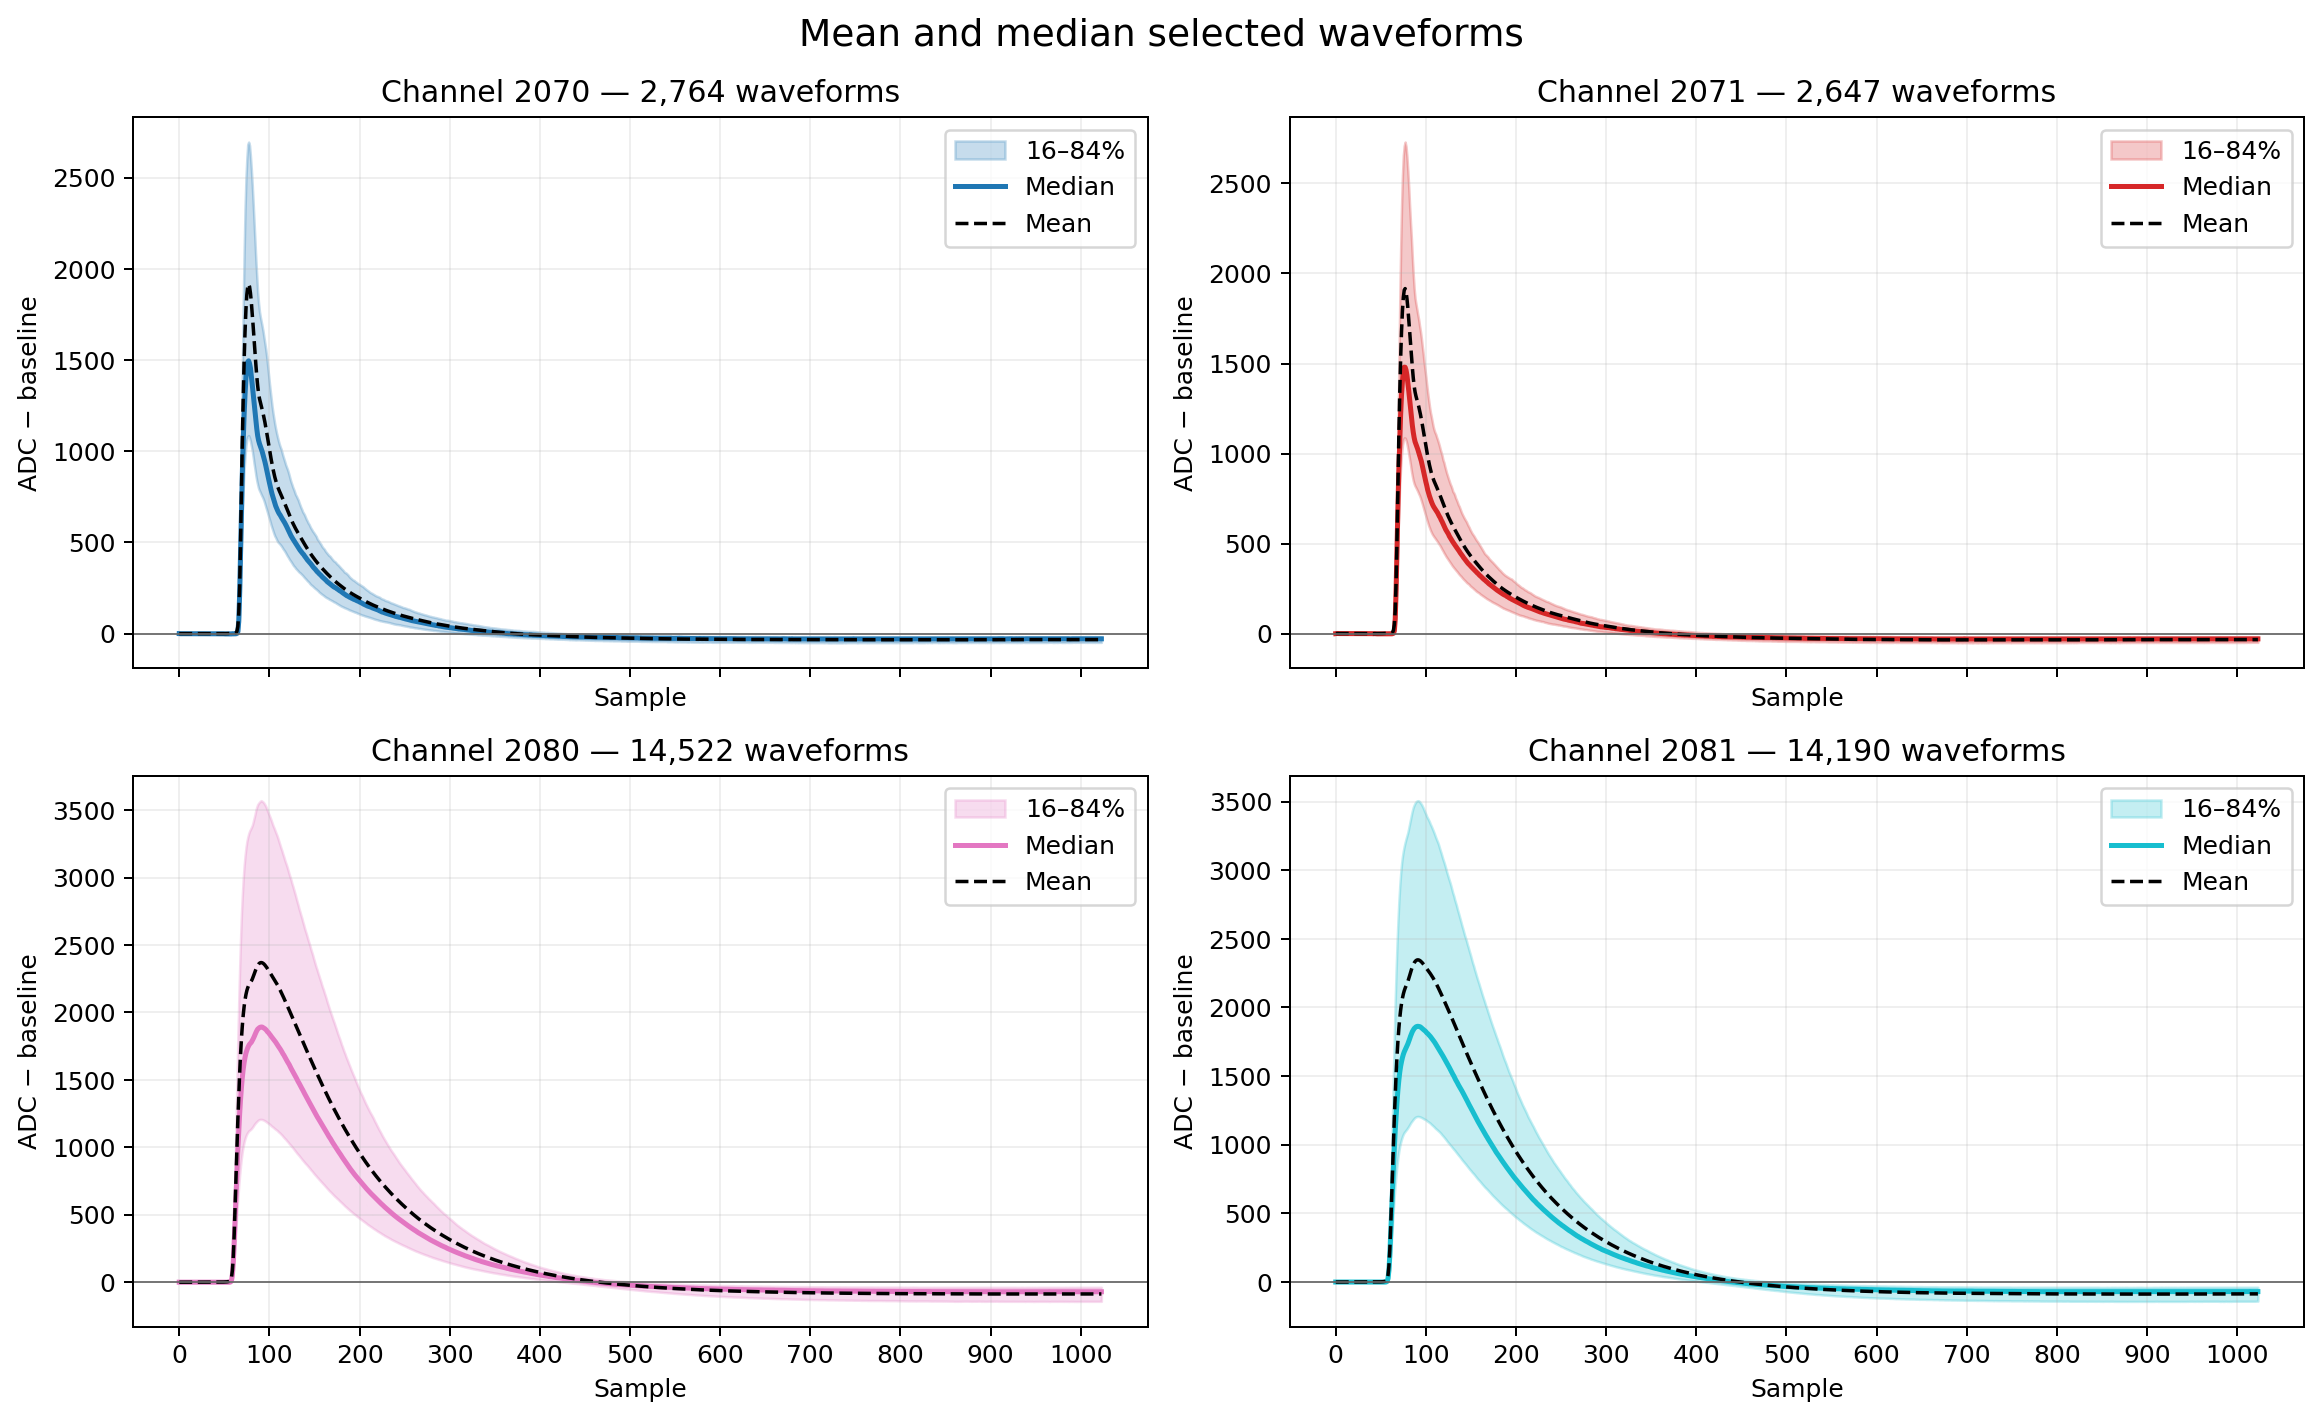

Saved mean_median_waveforms_run_039512_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.pdf and mean_median_waveforms_run_039512_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.png


In [12]:
# ------------------------------------------------------------------
# Plot mean and median baseline-subtracted waveforms by channel
# ------------------------------------------------------------------

plot_channels = [
    channel
    for channel in selected_channels
    if waveforms_by_channel[channel]
]

n_columns = 2
n_rows = int(np.ceil(len(plot_channels) / n_columns))

figure, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(13, 4 * n_rows),
    dpi=180,
    sharex=True,
    squeeze=False,
)

colors = plt.cm.tab10(np.linspace(0, 1, len(plot_channels)))

for axis, channel, color in zip(
    axes.flat,
    plot_channels,
    colors,
):
    records = waveforms_by_channel[channel]

    lengths = {len(record["adc"]) for record in records}
    if len(lengths) != 1:
        raise RuntimeError(
            f"Channel {channel} has inconsistent waveform lengths: "
            f"{sorted(lengths)}"
        )

    # Subtract each waveform's noise-region baseline.
    waveforms = np.stack(
        [
            record["adc"].astype(np.float32)
            - float(record["baseline"])
            for record in records
        ]
    )

    samples = np.arange(waveforms.shape[1])

    mean_waveform = np.mean(waveforms, axis=0)
    median_waveform = np.median(waveforms, axis=0)
    percentile_16, percentile_84 = np.percentile(
        waveforms,
        [16, 84],
        axis=0,
    )

    axis.fill_between(
        samples,
        percentile_16,
        percentile_84,
        color=color,
        alpha=0.25,
        label="16–84%",
    )

    axis.plot(
        samples,
        median_waveform,
        color=color,
        linewidth=2.0,
        label="Median",
    )

    axis.plot(
        samples,
        mean_waveform,
        color="black",
        linestyle="--",
        linewidth=1.4,
        label="Mean",
    )

    axis.axhline(
        0,
        color="0.4",
        linewidth=0.7,
    )

    axis.set_title(
        f"Channel {channel} — {len(records):,} waveforms"
    )
    axis.set_xlabel("Sample")
    axis.set_ylabel("ADC − baseline")
    axis.xaxis.set_major_locator(MultipleLocator(100))
    axis.grid(alpha=0.2)
    axis.legend(loc="upper right")
    np.savez_compressed(
        f"channel_{channel}_{LABEL}.npz",
        samples=samples,
        mean=mean_waveform,
        median=median_waveform,
        percentile_16=percentile_16,
        percentile_84=percentile_84,
    )

# Hide unused panels.
for axis in axes.flat[len(plot_channels):]:
    axis.set_visible(False)

figure.suptitle(
    "Mean and median selected waveforms",
    fontsize=15,
)

figure.tight_layout()

output_stem = f"mean_median_waveforms_{LABEL}"

figure.savefig(
    f"{output_stem}.pdf",
    bbox_inches="tight",
    transparent=True,
)
figure.savefig(
    f"{output_stem}.png",
    bbox_inches="tight",
    transparent=True,
)

plt.show()

print(f"Saved {output_stem}.pdf and {output_stem}.png")